# ExoLinker: Full Planetary Profile Generation
This notebook demonstrates how to couple an `exowrap` atmosphere model with a `fuzzycore` interior model to generate a continuous, mathematically rigorous planetary profile.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import our newly built exolinker package!
from exoweave import ExoCoupler, save_converged_model
from exowrap.output import ExoremOut
from fuzzycore import constants as c

# Set matplotlib style for nice scientific plots
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['font.size'] = 12

In [2]:
target_params = {
    "mass": 1.0,               # Jupiter masses
    "T_irr": 1100.0,           # Irradiation temperature (K)
    "T_int": 400.0,            # Intrinsic temperature (K)
    "Met": 0.0,                # Metallicity (log10 Z/Z_solar)
    "core_mass_earth": 15.0,   # Solid core mass in Earth masses
    "iron_fraction": 0.33,     # Earth-like core composition
    "f_sed": 1.0,              # Cloud sedimentation
    "kzz": 8.0,                # Eddy diffusion (log10)
    "debug": False
}

# 2. Define the numerical configuration for the solver
config = {
    "resolution": 50,                  
    "max_iterations": 15,              
    "mass_convergence_threshold": 0.01,
    "p_bottom_bar": 1000.0,
    "output_dir": "./outputs/grid_run",

    # --- Resolution Setup ---
    "resolution": 50,           # The fast, iterative solving resolution
    "target_resolution": 500    # The final, 1-time forward pass resolution!
}

In [3]:
# 3. Initialize the Orchestrator
coupler = ExoCoupler(target_params=target_params, config=config)

# 4. Fire the main solver loop! (This will take a few minutes)
print("🚀 Launching ExoLinker...")
results = coupler.run()

if results['status'] == 'converged':
    print(f"\n✅ Success! Converged in {results['iterations']} iterations.")
    print(f"Final T_int: {results['final_params']['T_int']:.1f} K")
    print(f"Final g_1bar: {results['final_params']['g_1bar']:.2f} m/s²")
else:
    print("\n❌ Solver failed to converge. Check the history for details.")


if results['status'] == 'failed':
    # Now this will successfully grab the DataFrame!
    raw_atm = results['atmosphere_raw']
    print("\n--- Failed Run Diagnostics ---")
    
    # Expose the ExoremOut properties
    exo = ExoremOut(raw_atm)
    
    print(f"Atmosphere T_int used: {exo.t_int:.1f} K")
    print(f"Atmosphere Gravity used: {exo.gravity[-1]:.2f} m/s²")
    
    # Find the boundary conditions it tried to pass to fuzzycore
    p_levels_bar = exo.pressure_levels / 1e5
    t_levels = exo.temperature_levels
    
    # Let's see what the temperature is at 100 bar!
    idx_link = np.argmin(np.abs(p_levels_bar - config['p_link_target_bar']))
    
    print(f"Deepest Exorem Boundary: P = {p_levels_bar[idx_link]:.2f} bar, T = {t_levels[idx_link]:.1f} K")


INFO: 💡 Smart Initialization: Guessed g = 24.78 m/s² for M = 1.0 M_Jup


🚀 Launching ExoLinker...


INFO: 🌌 Grid Setup: Generated mathematical cold-start prior down to 1000.0 bars.
INFO: 
INFO: 🔄 ITERATION 1/15 | Target Mass: 1.0 M_Jup | g: 24.78 m/s²
INFO: ==================================================
INFO: Starting ExoREM Simulation...
INFO: Generated namelist at /private/var/folders/ld/pl_0zzs158sb8h6_y3mrd0lm0000gp/T/tmpx0hw47cy/input.nml
INFO: Running Fortran backend from /Users/cwilkinson/.exowrap/exorem_source/dist/dist/exorem/bin...
INFO: Parsing results from /private/var/folders/ld/pl_0zzs158sb8h6_y3mrd0lm0000gp/T/tmpx0hw47cy/outputs/exowrap_run.h5...
INFO: Simulation complete.
INFO: 🔗 Dynamic Junction: Anchoring to thickest convective block at P = 44.67 bar
INFO: Calculating Z_base and Y_ratio from atmospheric VMRs at 44.66835921509632 bar.
INFO: 🧪 Chemical Sync: Derived Z_base = 0.0137, Y_ratio = 0.2502 (from X=0.7396, Y=0.2467)


--- Loading Raw EOS Tables (From Disk) ---
  > Loading Hydrogen...
  > Loading Helium...
  > Loading Water...
  > Loading Rock...
  > Loading Iron...
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


INFO: 📊 Breakdown: Interior Mass = 1.4648 M_Jup
INFO: 📊 Breakdown: Atm Mass = 0.000009 M_Jup (0.001% of total)
INFO: 📊 Results: Total Calc Mass = 1.465 M_Jup (Error: 46.48%)
INFO: 📊 Results: True Measured T_int = 324.7 K (Input dial: 400.0 K)
INFO: ✨ Upgrading atmosphere to R=500 for iteration 1...
INFO: Starting ExoREM Simulation...
INFO: Generated namelist at /private/var/folders/ld/pl_0zzs158sb8h6_y3mrd0lm0000gp/T/tmpbvagyt38/input.nml
INFO: Running Fortran backend from /Users/cwilkinson/.exowrap/exorem_source/dist/dist/exorem/bin...


...

🚀 Upgrading simulation to R=500...
💾 Locked P-T profile saved to: /Users/cwilkinson/Documents/Work/Research/Research/Codes/exoweave/outputs/grid_run/high_res_tmp_49925594/locked_pt_profile.dat
⚡ Executing 0-iteration forward pass...


INFO: Parsing results from /private/var/folders/ld/pl_0zzs158sb8h6_y3mrd0lm0000gp/T/tmpvh80darn/outputs/exowrap_run.h5...
INFO: 💾 Permanently saved HDF5 to: /Users/cwilkinson/Documents/Work/Research/Research/Codes/exoweave/outputs/grid_run/high_res_tmp_49925594/exorem_Tint316.7241145395924_g17.12302406729851.h5
INFO: Simulation complete.
INFO: 🌟 High-resolution upgrade seamlessly injected!
INFO: Stitching profiles at P_link = 97.16 bar
INFO: 🌟 Computing Mega-Catalog Photometry (Cached)...


🎉 High-resolution upgrade complete!


INFO: ✅ Successfully cached and computed 101 photometric bands!
INFO: ✅ CONVERGED in 4 iterations!
INFO: 💾 Converged model saved successfully to: /Users/cwilkinson/Documents/Work/Research/Research/Codes/exoweave/outputs/grid_run/target/M_1.000_Tirr_1100.0_Tint_316.7_Met_0.00_Core_15.0_fsed_1.0_kzz_8.0.pkl



✅ Success! Converged in 4 iterations.
Final T_int: 316.7 K
Final g_1bar: 17.12 m/s²


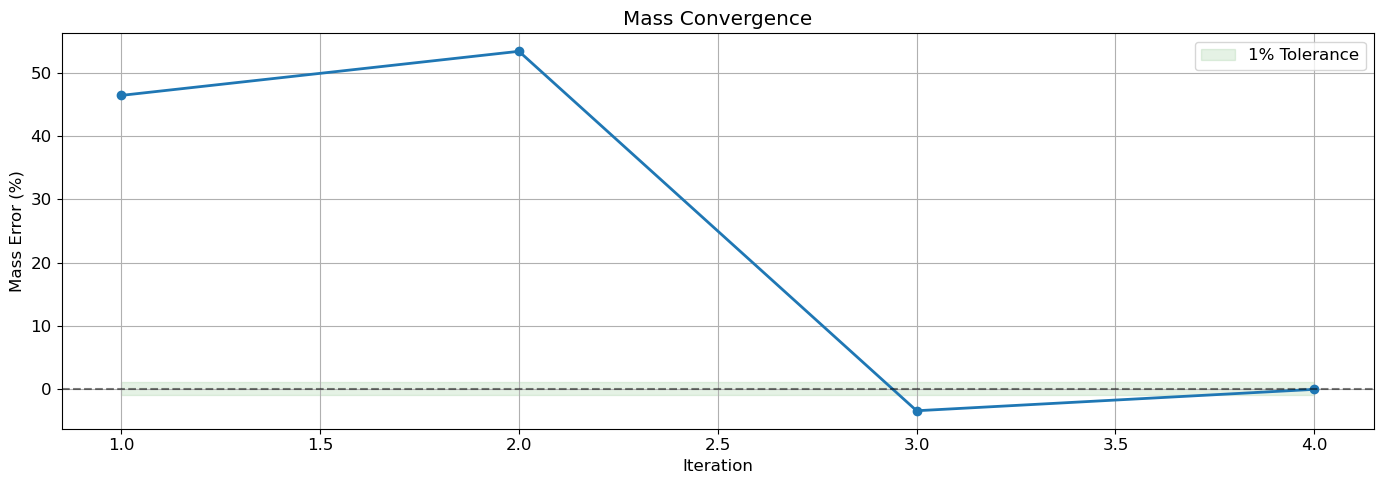

In [4]:
# 5. Visualize the Secant Method at work
history = coupler.history

fig, (ax1) = plt.subplots(1, 1, figsize=(14, 5))

# Gravity Error Plot
ax1.plot(history['iteration'], np.array(history['mass_error']) * 100, marker='o', color='tab:blue', lw=2)
ax1.axhline(0, color='black', linestyle='--', alpha=0.5)
ax1.fill_between(history['iteration'], -1, 1, color='green', alpha=0.1, label="1% Tolerance")
ax1.set_title("Mass Convergence")
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Mass Error (%)")
ax1.legend()


plt.tight_layout()
plt.show()

In [9]:
results

{'status': 'converged',
 'iterations': 4,
 'final_params': {'mass': 1.0,
  'T_irr': 1100.0,
  'T_int': 316.7241145395924,
  'Met': 0.0,
  'core_mass_earth': 15.0,
  'iron_fraction': 0.33,
  'f_sed': 1.0,
  'kzz': 8.0,
  'debug': False,
  'g_1bar': 17.12302406729851,
  'atmosphere_parameters': {'pressure_max': 100000000.0},
  'paths': {'path_temperature_profile': ''},
  'retrieval_parameters': {'temperature_profile_file': '/Users/cwilkinson/Documents/Work/Research/Research/Codes/exoweave/outputs/grid_run/high_res_tmp_49925594/locked_pt_profile.dat',
   'n_iterations': 0},
  'z_base': 0.015175964249675267,
  'Y_ratio': 0.25013227228128154,
  'T_int_input_dial': 400.0,
  'true_mass_Mjup': 0.999022580200918,
  'p_link_bar': 97.16279515771062},
 'stitched_profile':       Pressure_Pa  Pressure_bar      Radius_m  Temperature_K  Density_kgm3  \
 0    1.000000e-01  1.000000e-06  9.062996e+07     746.494547  3.758455e-08   
 1    1.295687e-01  1.295687e-06  9.057101e+07     745.695451  4.875002e

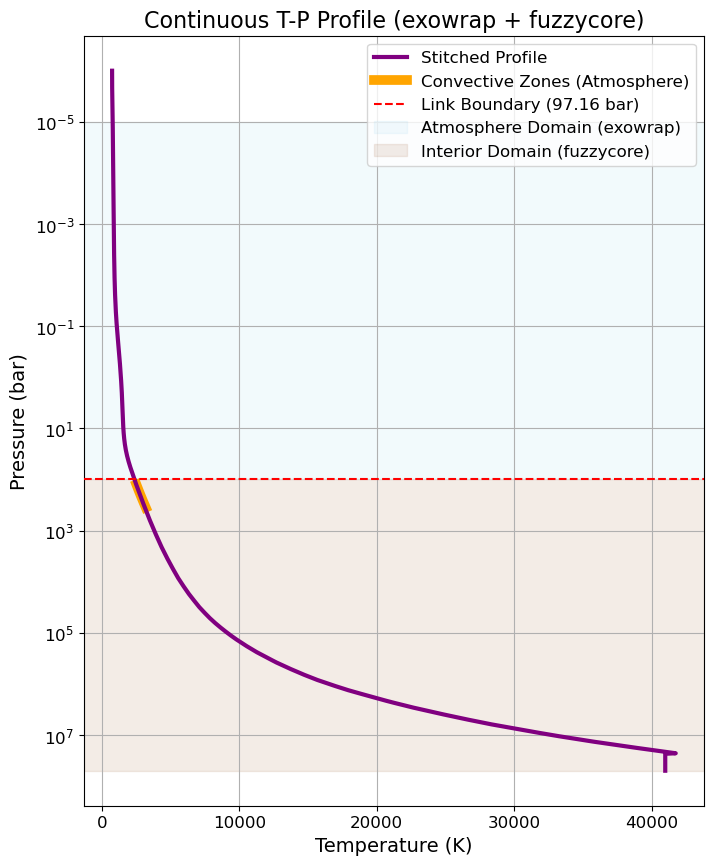

In [5]:
# 6. Visualize the continuous planetary profile
if results['status'] == 'converged':
    df = results['stitched_profile']
    p_link = results['final_params']['p_link_bar']
    
    fig, ax = plt.subplots(figsize=(8, 10))
    
    # 1. Plot the full stitched profile
    ax.plot(df['Temperature_K'], df['Pressure_bar'], color='purple', lw=3, zorder=3, label='Stitched Profile')
    
    # 2. Extract and overlay the convective zones from the atmosphere!
    atm_raw = results['atmosphere_raw']
    p_atm_bar = atm_raw['/outputs/levels/pressure'].iloc[0] / 1e5
    t_atm = atm_raw['/outputs/levels/temperature'].iloc[0]
    is_conv = atm_raw['/outputs/levels/is_convective'].iloc[0].astype(bool)
    
    # Replace all non-convective temperatures with NaN
    t_conv = np.where(is_conv, t_atm, np.nan)
    
    # Plot the bold overlay (Matplotlib automatically skips the NaNs!)
    ax.plot(t_conv, p_atm_bar, color='orange', lw=7, zorder=2, label='Convective Zones (Atmosphere)')
    
    # 3. Draw a line showing exactly where the two models linked
    ax.axhline(p_link, color='red', linestyle='--', zorder=4, label=f'Link Boundary ({p_link:.2f} bar)')
    
    # 4. Format the axes for atmospheric science standards (log pressure, inverted)
    ax.set_yscale('log')
    ax.invert_yaxis()
    ax.set_xlabel("Temperature (K)", fontsize=14)
    ax.set_ylabel("Pressure (bar)", fontsize=14)
    ax.set_title("Continuous T-P Profile (exowrap + fuzzycore)", fontsize=16)
    
    # 5. Fill background colors to show domains
    ax.axhspan(1e-5, p_link, color='skyblue', alpha=0.1, label='Atmosphere Domain (exowrap)')
    ax.axhspan(p_link, df['Pressure_bar'].max(), color='saddlebrown', alpha=0.1, label='Interior Domain (fuzzycore)')
    
    ax.legend(loc='upper right')
    plt.show()

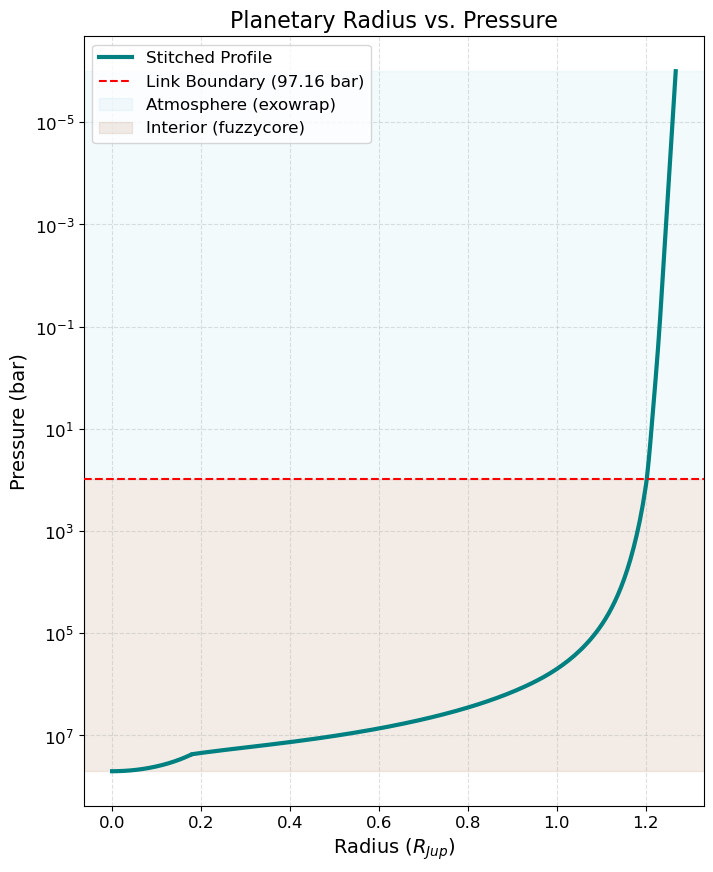

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure we have a converged result to plot
if results['status'] == 'converged':
    df = results['stitched_profile']
    p_link = results['final_params']['p_link_bar']
    
    # Handle column names dynamically (in case your master profile uses meters instead of Jupiter Radii)
    if 'Radius_Rjup' in df.columns:
        r_col = 'Radius_Rjup'
        x_label = "Radius ($R_{Jup}$)"
    elif 'Radius_m' in df.columns:
        # Convert meters to Jupiter radii on the fly (1 R_Jup = 71,492,000 m)
        df['Radius_Rjup_tmp'] = df['Radius_m'] / 71492000.0
        r_col = 'Radius_Rjup_tmp'
        x_label = "Radius ($R_{Jup}$)"
    else:
        # Fallback if standard names aren't found
        r_col = [col for col in df.columns if 'rad' in col.lower()][0]
        x_label = "Radius"
    
    fig, ax = plt.subplots(figsize=(8, 10))
    
    # 1. Plot the continuous Radius vs. Pressure curve
    ax.plot(df[r_col], df['Pressure_bar'], color='teal', lw=3, zorder=3, label='Stitched Profile')
    
    # 2. Draw a line showing exactly where the two models linked
    ax.axhline(p_link, color='red', linestyle='--', zorder=4, label=f'Link Boundary ({p_link:.2f} bar)')
    
    # 3. Format the axes (Log pressure, inverted so the deep core is at the bottom)
    ax.set_yscale('log')
    ax.invert_yaxis()
    ax.set_xlabel(x_label, fontsize=14)
    ax.set_ylabel("Pressure (bar)", fontsize=14)
    ax.set_title("Planetary Radius vs. Pressure", fontsize=16)
    
    # 4. Fill background colors to show physical domains
    ax.axhspan(df['Pressure_bar'].min(), p_link, color='skyblue', alpha=0.1, label='Atmosphere (exowrap)')
    ax.axhspan(p_link, df['Pressure_bar'].max(), color='saddlebrown', alpha=0.1, label='Interior (fuzzycore)')
    
    # Add a grid for easier reading of specific depths
    plt.grid(True, which="both", ls="--", alpha=0.4)
    ax.legend(loc='upper left')
    
    plt.show()
else:
    print("The model did not converge. Please check the logs!")

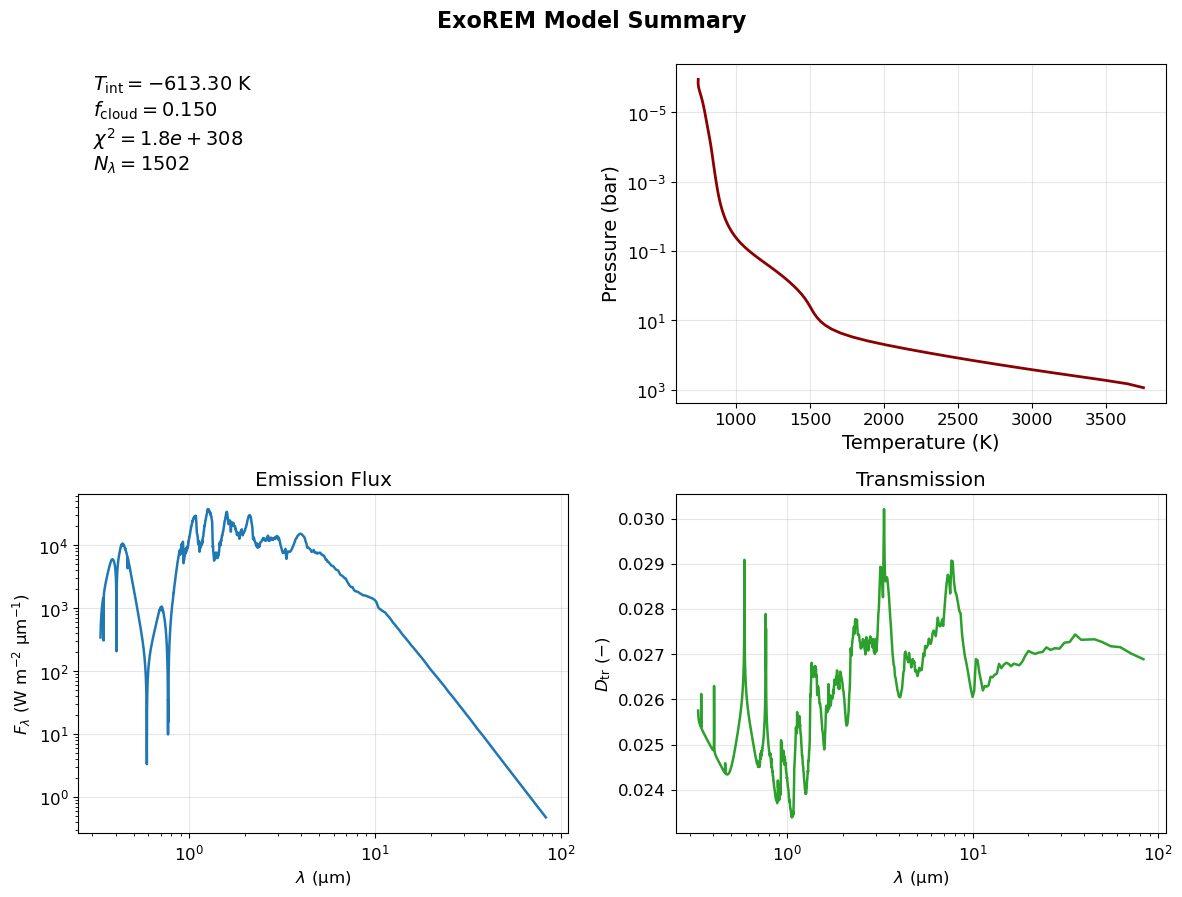

In [7]:
import matplotlib.pyplot as plt
from exowrap.plotting import plot_model_summary

if results['status'] == 'converged':
    # Extract the raw ExoREM DataFrame from your converged results
    atm_df = results['atmosphere_raw']
    
    # Generate the full 4-panel summary
    fig, axes = plot_model_summary(atm_df)
    
    plt.show()
else:
    print("The model did not converge, no atmosphere to plot!")

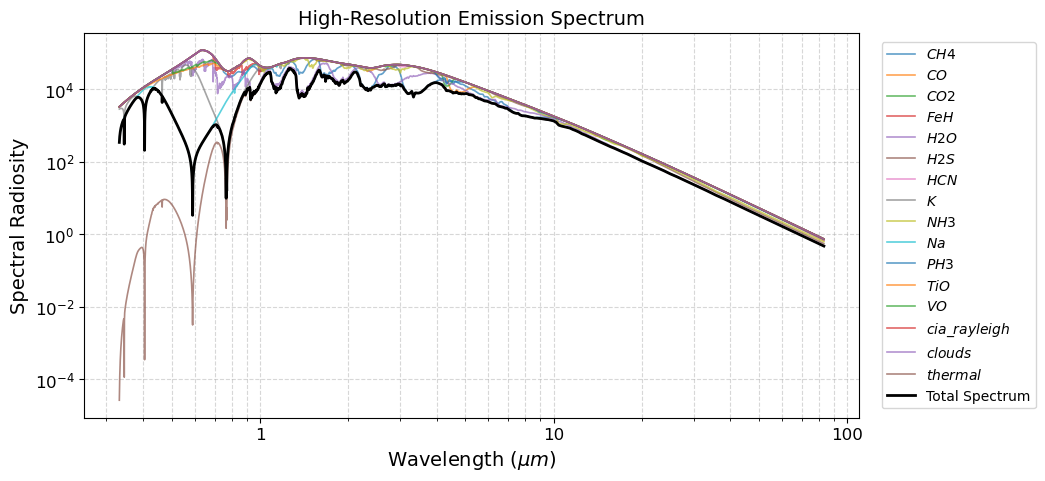

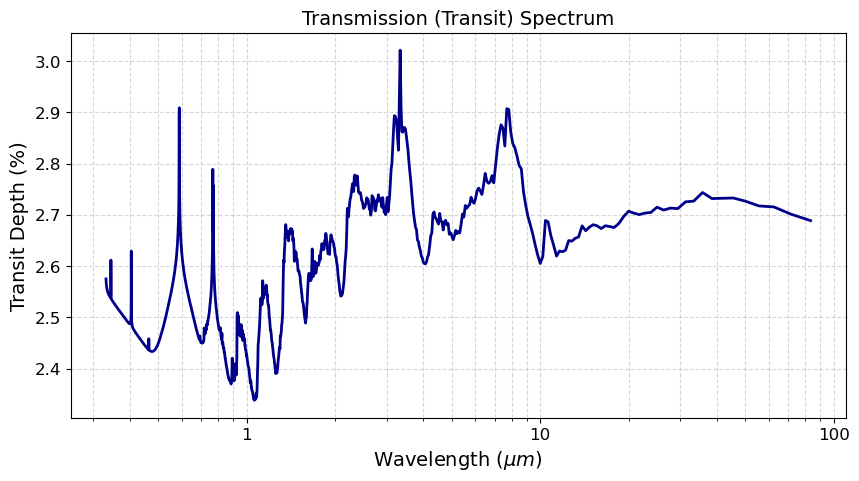

In [8]:
import matplotlib.pyplot as plt
from exowrap.plotting import plot_emission_spectrum, plot_transmission_spectrum

if results['status'] == 'converged':
    atm_df = results['atmosphere_raw']
    
    # 1. Plot the Emission Spectrum (with individual molecular contributions)
    fig1, ax1 = plt.subplots(figsize=(10, 5))
    plot_emission_spectrum(
        results_df=atm_df, 
        ax=ax1, 
        title="High-Resolution Emission Spectrum", 
        color="black",
        contributions=True  # Turns on the background molecular lines!
    )
    plt.show()

    # 2. Plot the Transmission Spectrum
    fig2, ax2 = plt.subplots(figsize=(10, 5))
    plot_transmission_spectrum(
        results_df=atm_df, 
        ax=ax2, 
        title="Transmission (Transit) Spectrum", 
        color="darkblue",
        contributions=False 
    )
    plt.show()